<a href="https://colab.research.google.com/github/Sugandha-B/CyberSecurity_Project/blob/main/Malware_detection_using_ML.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [6]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix

# 1. Load your dynamic analysis csv
# Let's assume your dataset columns are: [Hash, LdrLoadDll, RegOpenKey, NtWriteVirtualMemory, label]
df = pd.read_csv("/content/dynamic_api_call.csv")

# 2. Inspect the data (Good practice for an intern!)
print("Dataset Shape:", df.shape)
print(df.head())



Dataset Shape: (43876, 102)
                               hash  t_0  t_1  t_2  t_3  t_4  t_5  t_6  t_7  \
0  071e8c3f8922e186e57548cd4c703a5d  112  274  158  215  274  158  215  298   
1  33f8e6d08a6aae939f25a8e0d63dd523   82  208  187  208  172  117  172  117   
2  b68abd064e975e1c6d5f25e748663076   16  110  240  117  240  117  240  117   
3  72049be7bd30ea61297ea624ae198067   82  208  187  208  172  117  172  117   
4  c9b3700a77facf29172f32df6bc77f48   82  240  117  240  117  240  117  240   

   t_8  ...  t_91  t_92  t_93  t_94  t_95  t_96  t_97  t_98  t_99  malware  
0   76  ...    71   297   135   171   215    35   208    56    71        1  
1  172  ...    81   240   117    71   297   135   171   215    35        1  
2  240  ...    65   112   123    65   112   123    65   113   112        1  
3  172  ...   208   302   208   302   187   208   302   228   302        1  
4  117  ...   209   260    40   209   260   141   260   141   260        1  

[5 rows x 102 columns]


In [7]:
print(df.columns)

Index(['hash', 't_0', 't_1', 't_2', 't_3', 't_4', 't_5', 't_6', 't_7', 't_8',
       ...
       't_91', 't_92', 't_93', 't_94', 't_95', 't_96', 't_97', 't_98', 't_99',
       'malware'],
      dtype='object', length=102)


In [8]:
X = df.drop(['hash', 'malware'], axis=1, errors='ignore')

In [9]:
y = df['malware']

In [10]:
X = X.fillna(0)

In [11]:
# 4. Split the dataset into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

# 5. Train the Random Forest classifier
behavioral_model = RandomForestClassifier(
    n_estimators=150,
    random_state=42
)

In [12]:
behavioral_model.fit(X_train, y_train)

print("\n==============================")
print("Training Complete!")
print("==============================")


Training Complete!


In [13]:
y_pred = behavioral_model.predict(X_test)

In [14]:
print("\nAccuracy:")
print(f"{accuracy_score(y_test, y_pred) * 100:.2f}%")

print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred))

print("\nClassification Report:")
print(classification_report(y_test, y_pred))



Accuracy:
98.91%

Confusion Matrix:
[[ 127   89]
 [   7 8553]]

Classification Report:
              precision    recall  f1-score   support

           0       0.95      0.59      0.73       216
           1       0.99      1.00      0.99      8560

    accuracy                           0.99      8776
   macro avg       0.97      0.79      0.86      8776
weighted avg       0.99      0.99      0.99      8776



In [15]:
feature_importance = pd.DataFrame({
    'Feature': X.columns,
    'Importance': behavioral_model.feature_importances_
})

feature_importance = feature_importance.sort_values(
    by='Importance',
    ascending=False
)

print("\nTop 10 Most Important Features:")
print(feature_importance.head(10))



Top 10 Most Important Features:
   Feature  Importance
1      t_1    0.080196
90    t_90    0.063808
98    t_98    0.029921
63    t_63    0.021970
75    t_75    0.021721
0      t_0    0.017647
85    t_85    0.017603
2      t_2    0.017007
37    t_37    0.016482
83    t_83    0.016344


In [16]:
import joblib

joblib.dump(behavioral_model, "behavioral_malware_model.pkl")
print("\nModel saved as behavioral_malware_model.pkl")


Model saved as behavioral_malware_model.pkl


In [18]:
from sklearn.model_selection import cross_val_score

scores = cross_val_score(behavioral_model, X, y, cv=5)
print("Cross-validation Accuracy:", scores.mean())

Cross-validation Accuracy: 0.9895158954621124


In [19]:
from sklearn.metrics import roc_auc_score

probs = behavioral_model.predict_proba(X_test)[:, 1]
print("ROC-AUC:", roc_auc_score(y_test, probs))

ROC-AUC: 0.9899273104880582


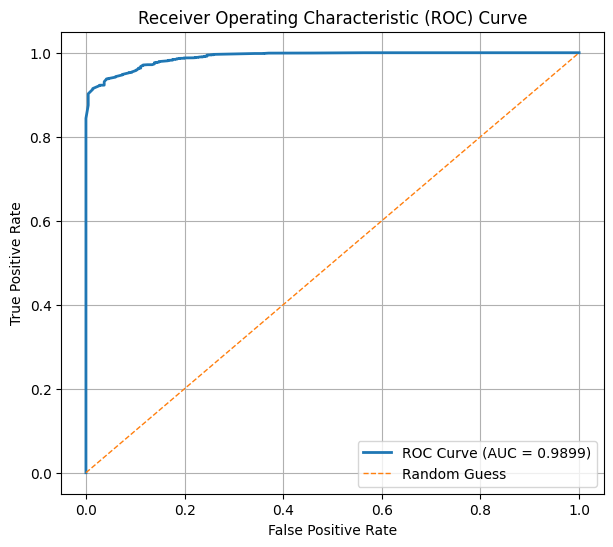

In [20]:
import matplotlib.pyplot as plt
from sklearn.metrics import (
    roc_curve,
    auc,
    precision_recall_curve,
    average_precision_score
)

# Predict probabilities for the positive class (malware)
y_prob = behavioral_model.predict_proba(X_test)[:, 1]

# ==============================
# ROC Curve
# ==============================
fpr, tpr, _ = roc_curve(y_test, y_prob)
roc_auc = auc(fpr, tpr)

plt.figure(figsize=(7,6))
plt.plot(fpr, tpr, linewidth=2, label=f'ROC Curve (AUC = {roc_auc:.4f})')
plt.plot([0, 1], [0, 1], linestyle='--', linewidth=1, label='Random Guess')

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("Receiver Operating Characteristic (ROC) Curve")
plt.legend(loc="lower right")
plt.grid(True)

plt.show()

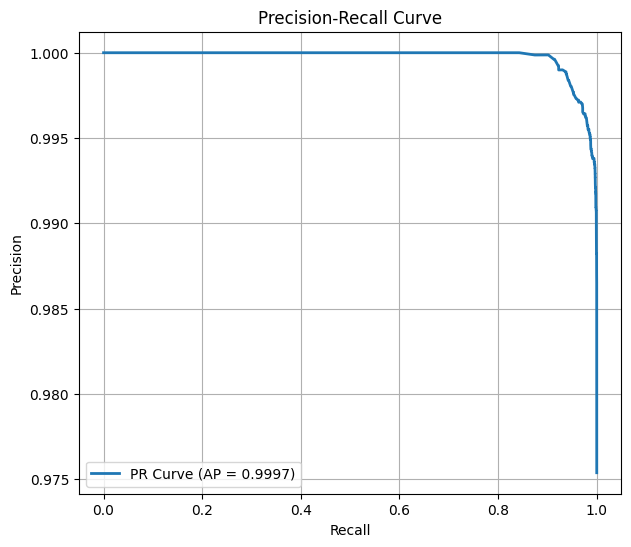

In [21]:
# ==============================
# Precision-Recall Curve
# ==============================
precision, recall, _ = precision_recall_curve(y_test, y_prob)
ap = average_precision_score(y_test, y_prob)

plt.figure(figsize=(7,6))
plt.plot(recall, precision, linewidth=2,
         label=f'PR Curve (AP = {ap:.4f})')

plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Precision-Recall Curve")
plt.legend(loc="lower left")
plt.grid(True)

plt.show()